In [1]:
import numpy as np
import cupy as cp
import matplotlib.pyplot as plt

from aispy.psmap import load_psmap, PSMAPSurrogate

import sys, os
sys.path.insert(0, os.path.expanduser('~/local/aispy'))

# start by getting the psmaps
psmap = load_psmap('../output-files/PSGRID4D_CONFOCAL_FINE_Z0.h5')

surrogate = PSMAPSurrogate(psmap, t_det=3.8, use_gpu=True)

In [4]:
def paps(mux0,muvx0,muy0,muvy0,sx0,svx0,sy0,svy0):
    N=int(1e6)
    mu = [mux0,muy0,muvx0,muvy0]
    sigma = np.diag([sx0,sy0,svx0,svy0])
    coords = np.random.multivariate_normal(mu, sigma, size=N).T
    dphi, _, _ = surrogate.eval(coords[0],coords[1],coords[2],coords[3])
    dphi = dphi[0,:]
    return np.mean(dphi), dphi

from tqdm import tqdm
sx = 10e-6
n = 10
params = np.random.multivariate_normal([0,0,0,0,100e-6,100e-6,100e-6,100e-6],np.diag([sx]*8), n)

dphis = []
for i in tqdm(range(len(params))):
    p = params[i]
    mean, _ = paps(*p)
    dphis.append(mean)

params = np.random.multivariate_normal([0,0,0,0,100e-6,100e-6,100e-6,100e-6],np.zeros((8,8)), n)   

dphis_null = []
for i in tqdm(range(len(params))):
    p = params[i]
    mean, _ = paps(*p)
    dphis_null.append(mean)

  0%|          | 0/10 [00:00<?, ?it/s]/tmp/ipykernel_383150/2702093543.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  coords = np.random.multivariate_normal(mu, sigma, size=N).T
100%|██████████| 10/10 [00:04<00:00,  2.41it/s]


(array([4., 0., 0., 0., 0., 5., 0., 0., 0., 1.]),
 array([-27656699.56303209, -27656699.39014358, -27656699.21725507,
        -27656699.04436656, -27656698.87147805, -27656698.69858954,
        -27656698.52570103, -27656698.35281252, -27656698.17992401,
        -27656698.00703551, -27656697.834147  ]),
 <BarContainer object of 10 artists>)

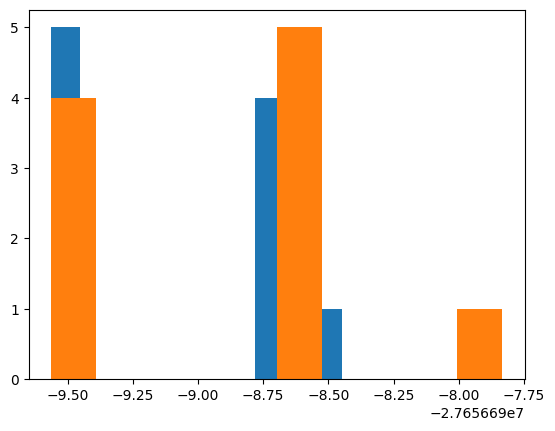

In [3]:
plt.hist(dphis)
plt.hist(dphis_null)

In [ ]:
def get_pspoints_dphi(mux0,muvx0,muy0,muvy0,sx0,svx0,sy0,svy0):
    N=int(1e6)
    mu = [mux0,muy0,muvx0,muvy0]
    sigma = np.diag([sx0,sy0,svx0,svy0])
    coords = np.random.multivariate_normal(mu, sigma, size=N).T
    dphi, _, _ = surrogate.eval(coords[0],coords[1],coords[2],coords[3])
    print(dphi.shape)
    dphi = dphi[0,:]
    return dphi, coords

params = np.random.multivariate_normal([0,0,0,0,100e-6,100e-6,100e-6,100e-6],np.diag([sx]*8), 1)   

dphi, coords = get_pspoints_dphi(*params[0])


/tmp/ipykernel_383150/1172218685.py:5: RuntimeWarning: covariance is not symmetric positive-semidefinite.
  coords = np.random.multivariate_normal(mu, sigma, size=N).T


ValueError: 'c' argument has 2 elements, which is inconsistent with 'x' and 'y' with size 1000000.

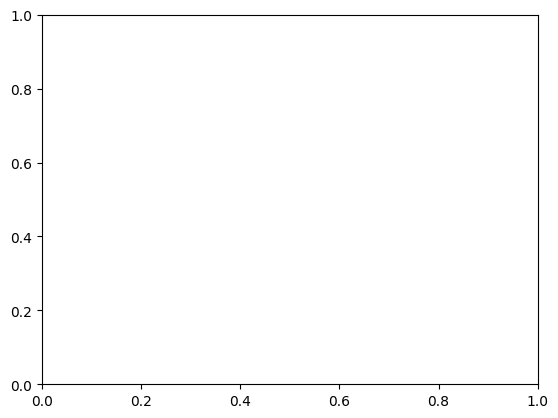

In [15]:
plt.scatter(coords[0],coords[1], c=dphi)

In [16]:
dphi.shape

(2,)